In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import common library functions for print style, data wrangling, data imputation
- force reload when this cell is executed, as the lib functions change frequently and
we don't want to use the cached versions

In [46]:
# imports needed for reloading
import importlib
import sys

# To avoid issues with cached python code that is often changing during development,
# we forcibly reload those modules
modules = ['lib.text_util', 'lib.wrangler', 'lib.imputer', 'lib.analyzer']

for module in modules:
    if module in sys.modules:
        importlib.reload(sys.modules[module])

# text helpers used to make text output more readable
import lib.text_util as tu

# data wrangling helpers
import lib.wrangler as wr

# data imputation helpers
import lib.imputer as im

# data analysis helpers
import lib.analyzer as da

# utility functions
import lib.utility as utl


# to test text_util, uncomment the following line
# tu.demo_text_print()

### Global configuration

In [47]:
# show dataframe values with commas and 2 decimal places
pd.options.display.float_format = '{:,.2f}'.format

### Read sales data, and show the dataframe

UNIQUE VALUES FOR OBJECT COLUMNS

📊 Column: Date
   Total unique values: 90
   First 10 values: ['1-Oct-2020', '2-Oct-2020', '3-Oct-2020', '4-Oct-2020', '5-Oct-2020', '6-Oct-2020', '7-Oct-2020', '8-Oct-2020', '9-Oct-2020', '10-Oct-2020']
   ... and 80 more
   Most frequent: 1-Oct-2020 (84 times)

📊 Column: Time
   Total unique values: 3
   Values: ['Morning', 'Afternoon', 'Evening']
   Most frequent: Morning (2520 times)

📊 Column: State
   Total unique values: 7
   Values: ['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS']
   Most frequent: WA (1080 times)

📊 Column: Group
   Total unique values: 4
   Values: ['Kids', 'Men', 'Women', 'Seniors']
   Most frequent: Kids (1890 times)


📊 Statistics for 'Sales' when grouped by 'Group':
         count       sum      mean       std              var   min     max  \
Group                                                                         
Kids      1890  85072500 45,011.90 31,871.49 1,015,791,943.96  5000  162500   
Men       1890  85750000 45,370.37 32,177.18 1,035,370,958.57  5000  160000   
Seniors   1890  84037500 44,464.29 32,195.36 1,036,541,206.61  5000  162500   
Women     1890  85442500 45,207.67 32,781.64 1,074,635,912.52  5000  162500   

           median  
Group              
Kids    35,000.00  
Men     35,000.00  
Seniors 35,000.00  
Women   35,000.00  
=== grouped_by_series ===
Class: <class 'pandas.core.groupby.generic.SeriesGroupBy'>
Class Name: SeriesGroupBy
Type: <class 'pandas.core.groupby.generic.SeriesGroupBy'>
Type name: SeriesGroupBy
String representation: <pandas.core.groupby.generic.SeriesGroupBy object at 0x112243560>...


📈 COEFFICIENT OF VARIATION (CV) - Higher = More Variable:
    Kids:

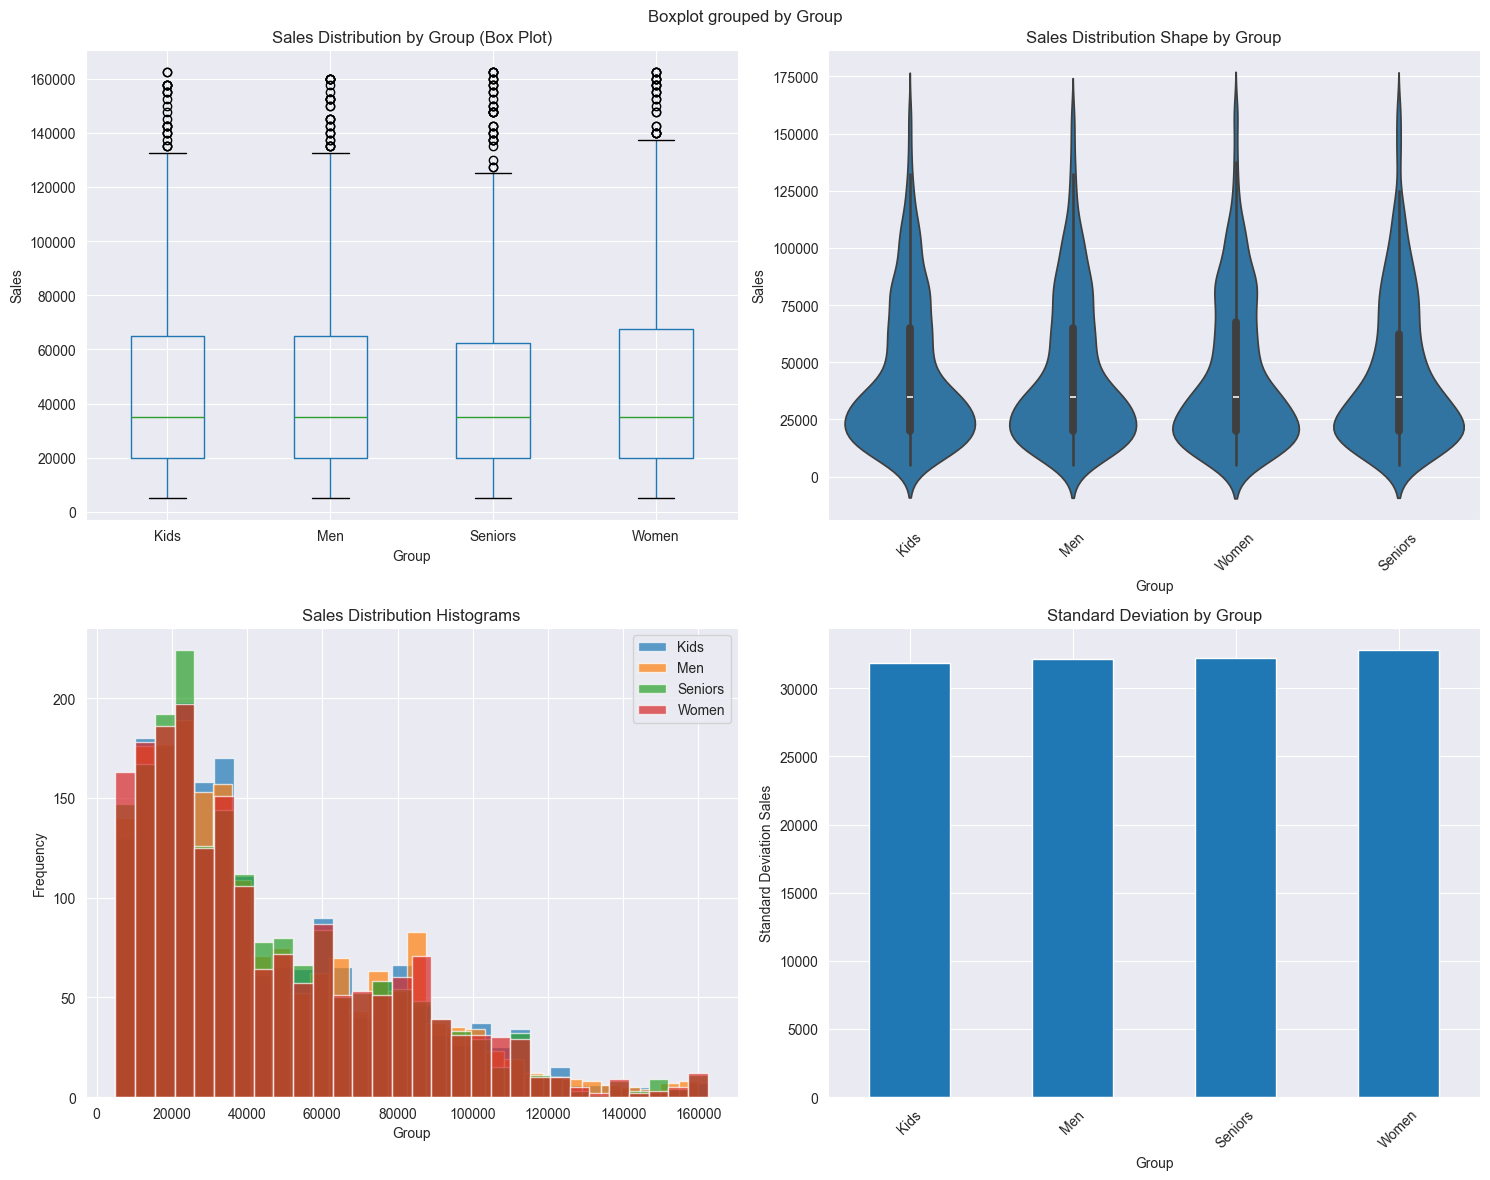


🔍 VARIANCE DECOMPOSITION:
    Kids variance: $1,015,791,943.96
     Men variance: $1,035,370,958.57
 Seniors variance: $1,036,541,206.61
   Women variance: $1,074,635,912.52

Total variance: $1,040,288,710.18
Within-group variance: $1,040,447,307.25
Between-group variance: $-158,597.07
Variance ratio (between/within): -0.0002


In [48]:
orig_sales = pd.read_csv('AusApparalSales4thQrt2020.csv')

sales = wr.normalize_object_columns_advanced(orig_sales, columns_case_styles={'State':'original'})
wr.show_unique_values_for_object_columns(sales, max_unique=10)
#sales
da.anova_for_column(sales, 'Group', 'Sales')
#da.statistical_group_test(sales, 'Group', 'Sales', 'Men')


# 1. Data Wrangling

In [ ]:
%%sql


### Display information about the data columns

In [49]:
wr.print_col_info(sales)

Columns: ['Date', 'Time', 'State', 'Group', 'Unit', 'Sales']
Shape: (7560, 6)

Dtypes:
Date     object
Time     object
State    object
Group    object
Unit      int64
Sales     int64
dtype: object

Sample values for object columns:
Date: ['1-Oct-2020', '1-Oct-2020', '1-Oct-2020']
Time: ['Morning', 'Morning', 'Morning']
State: ['WA', 'WA', 'WA']
Group: ['Kids', 'Men', 'Women']


### Show missing values

In [50]:
wr.print_missing_values_counts(sales)

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


Date     0
Time     0
State    0
Group    0
dtype: int64


### Show dataframe overview with info

In [51]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


### Show basic data statistics

In [52]:
sales.describe()

,Unit,Sales
count,"7,560.00","7,560.00"
mean,18.01,"45,013.56"
std,12.90,"32,253.51"
min,2.00,"5,000.00"
25%,8.00,"20,000.00"
50%,14.00,"35,000.00"
75%,26.00,"65,000.00"
max,65.00,"162,500.00"


### Convert DD-MMM-YYYY date strings into an actual date

In [53]:

# Convert Date column from string to datetime
# The format '%d-%b-%Y' matches DD-MMM-YYYY (e.g., "1-Oct-2020")
sales['Date'] = pd.to_datetime(sales['Date'], format='%d-%b-%Y')

# Verify the conversion
tu.print_heading("Date Column Conversion")
print(tu.bold_text("Date column info after conversion:"))
print(f"Data type: {sales['Date'].dtype}")
print(f"Sample values: {sales['Date'].head().tolist()}")

# Show the first few rows to confirm
print("\nFirst few rows with converted dates:")
print(sales[['Date', 'Time', 'State', 'Sales']].head())

Date column info after conversion:
Data type: datetime64[ns]
Sample values: [Timestamp('2020-10-01 00:00:00'), Timestamp('2020-10-01 00:00:00'), Timestamp('2020-10-01 00:00:00'), Timestamp('2020-10-01 00:00:00'), Timestamp('2020-10-01 00:00:00')]

First few rows with converted dates:
        Date       Time State  Sales
0 2020-10-01    Morning    WA  20000
1 2020-10-01    Morning    WA  20000
2 2020-10-01    Morning    WA  10000
3 2020-10-01    Morning    WA  37500
4 2020-10-01  Afternoon    WA   7500


### Add other date columns, week, month, quarter

In [54]:
sales['Week'] = sales['Date'].dt.isocalendar().week
sales['Month'] = sales['Date'].dt.month
sales['Quarter'] = sales['Date'].dt.quarter


# Missing values and new columns discussion

No missing values were found. There were no column values found matching
DEFAULT_MISSING_VALUES = ("", "NA", "N/A", "-", "null", "None", "?")

We converted the Date column into an actual date and added columns for week, month and quarter

### Data Normalization

In [55]:
# Data Normalization - as recommended in the requirements
from sklearn.preprocessing import MinMaxScaler

# Create a copy of the dataframe for normalization
sales_normalized = sales.copy()

# Apply normalization to numerical columns (Unit and Sales)
scaler = MinMaxScaler()
sales_normalized[['Unit_normalized', 'Sales_normalized']] = scaler.fit_transform(sales[['Unit', 'Sales']])

tu.print_heading("Original vs Normalized Samples")
print(tu.bold_text("Original Data Sample:"))
print(sales[['Unit', 'Sales', 'State', 'Group']].head())
print(tu.bold_text("Normalized Data Sample:"))
print(sales_normalized[['Unit_normalized', 'Sales_normalized', 'State', 'Group']].head())


sales_normalized

Original Data Sample:
   Unit  Sales State    Group
0     8  20000    WA     Kids
1     8  20000    WA      Men
2     4  10000    WA    Women
3    15  37500    WA  Seniors
4     3   7500    WA     Kids
Normalized Data Sample:
   Unit_normalized  Sales_normalized State    Group
0             0.10              0.10    WA     Kids
1             0.10              0.10    WA      Men
2             0.03              0.03    WA    Women
3             0.21              0.21    WA  Seniors
4             0.02              0.02    WA     Kids


,Date,Time,State,Group,Unit,Sales,Week,Month,Quarter,Unit_normalized,Sales_normalized
0,2020-10-01,Morning,WA,Kids,8,20000,40,10,4,0.10,0.10
1,2020-10-01,Morning,WA,Men,8,20000,40,10,4,0.10,0.10
2,2020-10-01,Morning,WA,Women,4,10000,40,10,4,0.03,0.03
3,2020-10-01,Morning,WA,Seniors,15,37500,40,10,4,0.21,0.21
4,2020-10-01,Afternoon,WA,Kids,3,7500,40,10,4,0.02,0.02
...,...,...,...,...,...,...,...,...,...,...,...
7555,2020-12-30,Afternoon,TAS,Seniors,14,35000,53,12,4,0.19,0.19
7556,2020-12-30,Evening,TAS,Kids,15,37500,53,12,4,0.21,0.21
7557,2020-12-30,Evening,TAS,Men,15,37500,53,12,4,0.21,0.21
7558,2020-12-30,Evening,TAS,Women,11,27500,53,12,4,0.14,0.14


### Double checking normalized data
- since the normalized values for Sales and Unit are the same, I wanted to double check them

In [56]:
min_sales = sales['Sales'].min()
max_sales = sales['Sales'].max()
min_unit = sales['Unit'].min()
max_unit = sales['Unit'].max()

sales_normal_denominator = max_sales - min_sales
unit_normal_denominator = max_unit - min_unit

for index, row in sales_normalized.iloc[:10].iterrows():
    # Your code here
    print(f"Index: {index}, Sales: {row['Sales']} ({row['Sales_normalized']}), Unit: {row['Unit']} ({row['Unit_normalized']})")
    normalized_sales = (row['Sales'] - min_sales) / sales_normal_denominator
    normalized_unit = (row['Unit'] - min_unit) / unit_normal_denominator

    print(f"calcd: {index}: Sales: {row['Sales']} ({normalized_sales})  Unit: {row['Unit']} ({normalized_unit})")


Index: 0, Sales: 20000 (0.09523809523809523), Unit: 8 (0.09523809523809523)
calcd: 0: Sales: 20000 (0.09523809523809523)  Unit: 8 (0.09523809523809523)
Index: 1, Sales: 20000 (0.09523809523809523), Unit: 8 (0.09523809523809523)
calcd: 1: Sales: 20000 (0.09523809523809523)  Unit: 8 (0.09523809523809523)
Index: 2, Sales: 10000 (0.031746031746031744), Unit: 4 (0.031746031746031744)
calcd: 2: Sales: 10000 (0.031746031746031744)  Unit: 4 (0.031746031746031744)
Index: 3, Sales: 37500 (0.20634920634920637), Unit: 15 (0.20634920634920634)
calcd: 3: Sales: 37500 (0.20634920634920634)  Unit: 15 (0.20634920634920634)
Index: 4, Sales: 7500 (0.015873015873015872), Unit: 3 (0.015873015873015872)
calcd: 4: Sales: 7500 (0.015873015873015872)  Unit: 3 (0.015873015873015872)
Index: 5, Sales: 25000 (0.12698412698412698), Unit: 10 (0.12698412698412698)
calcd: 5: Sales: 25000 (0.12698412698412698)  Unit: 10 (0.12698412698412698)
Index: 6, Sales: 7500 (0.015873015873015872), Unit: 3 (0.015873015873015872)
c

### NOTE: Normalization chosen instead of standardization.
We want all the features to contribute equally (bounded between 0-1)

### What normalized data reveals?
We see that Sales and Unit columns normalize to the same value, so that would imply that all units are the same price and that these two columns essentially convey the same information as to sales magnitude.

### Group By Analysis

In [57]:
# GroupBy Analysis - as requested in requirements
tu.print_heading("GroupBy Analysis")

# Show sales and units by state
wr.show_group_by_analysis_multi(sales, 'State',
    { 'Sales': ['sum', 'mean', 'count'], 'Unit': ['sum', 'mean'] },
    "State-wise Sales Analysis", ['Sales','sum'])

# Show sales and units by demographic groups
wr.show_group_by_analysis_multi(sales, 'Group',
    {'Sales': ['sum', 'mean', 'count'],'Unit': ['sum', 'mean'] },
    "Demographic Group-wise Sales Analysis", ['Sales','sum'])

# Show sales and units by time of day
wr.show_group_by_analysis_multi(sales, 'Time',
    {'Sales': ['sum', 'mean', 'count'], 'Unit': ['sum', 'mean']},
    "Time-wise Sales Analysis", ['Sales','sum'])


sort_by: ['Sales', 'sum']
sort_by[0]: Sales
sort_by[1]: sum
agg_cols: {'Sales': ['sum', 'mean', 'count'], 'Unit': ['sum', 'mean']}
Exception: 0



None
                Sales                              Unit        
                  sum        mean     count         sum    mean
State                                                          
VIC    105,565,000.00   97,745.37  1,080.00   42,226.00   39.10
NSW     74,970,000.00   69,416.67  1,080.00   29,988.00   27.77
SA      58,857,500.00   54,497.69  1,080.00   23,543.00   21.80
QLD     33,417,500.00   30,942.13  1,080.00   13,367.00   12.38
TAS     22,760,000.00   21,074.07  1,080.00    9,104.00    8.43
NT      22,580,000.00   20,907.41  1,080.00    9,032.00    8.36
WA      22,152,500.00   20,511.57  1,080.00    8,861.00    8.20
Total  340,302,500.00  315,094.91  7,560.00  136,121.00  126.04
sort_by: ['Sales', 'sum']
sort_by[0]: Sales
sort_by[1]: sum
agg_cols: {'Sales': ['sum', 'mean', 'count'], 'Unit': ['sum', 'mean']}
Exception: 0



None
                  Sales                              Unit       
                    sum        mean     count         sum   mean
Group                                                           
Men       85,750,000.00   45,370.37  1,890.00   34,300.00  18.15
Women     85,442,500.00   45,207.67  1,890.00   34,177.00  18.08
Kids      85,072,500.00   45,011.90  1,890.00   34,029.00  18.00
Seniors   84,037,500.00   44,464.29  1,890.00   33,615.00  17.79
Total    340,302,500.00  180,054.23  7,560.00  136,121.00  72.02
sort_by: ['Sales', 'sum']
sort_by[0]: Sales
sort_by[1]: sum
agg_cols: {'Sales': ['sum', 'mean', 'count'], 'Unit': ['sum', 'mean']}
Exception: 0



None
                    Sales                              Unit       
                      sum        mean     count         sum   mean
Time                                                              
Morning    114,207,500.00   45,320.44  2,520.00   45,683.00  18.13
Afternoon  114,007,500.00   45,241.07  2,520.00   45,603.00  18.10
Evening    112,087,500.00   44,479.17  2,520.00   44,835.00  17.79
Total      340,302,500.00  135,040.68  7,560.00  136,121.00  54.02


### Group by analysis on normalized data

In [58]:
# GroupBy Analysis - as requested in requirements
tu.print_heading("GroupBy Analysis")

# Show sales and units by state
wr.show_group_by_analysis_multi(sales_normalized, 'State',
    { 'Sales_normalized': ['sum', 'mean', 'count'], 'Unit_normalized': ['sum', 'mean'] },
    "Normalized State-wise Sales Analysis", ['Sales_normalized','sum'])

# Show sales and units by demographic groups
wr.show_group_by_analysis_multi(sales_normalized, 'Group',
    {'Sales_normalized': ['sum', 'mean', 'count'],'Unit_normalized': ['sum', 'mean'] },
    "Normalized Demographic Group-wise Sales Analysis", ['Sales_normalized','sum'])

# Show sales and units by time of day
wr.show_group_by_analysis_multi(sales_normalized, 'Time',
    {'Sales_normalized': ['sum', 'mean', 'count'], 'Unit_normalized': ['sum', 'mean']},
    "Normalized Time-wise Sales Analysis", ['Sales_normalized','sum'])


sort_by: ['Sales_normalized', 'sum']
sort_by[0]: Sales_normalized
sort_by[1]: sum
agg_cols: {'Sales_normalized': ['sum', 'mean', 'count'], 'Unit_normalized': ['sum', 'mean']}
Exception: 0



None
      Sales_normalized                 Unit_normalized      
                   sum  mean     count             sum  mean
State                                                       
VIC             635.97  0.59  1,080.00          635.97  0.59
NSW             441.71  0.41  1,080.00          441.71  0.41
SA              339.41  0.31  1,080.00          339.41  0.31
QLD             177.89  0.16  1,080.00          177.89  0.16
TAS             110.22  0.10  1,080.00          110.22  0.10
NT              109.08  0.10  1,080.00          109.08  0.10
WA              106.37  0.10  1,080.00          106.37  0.10
Total         1,920.65  1.77  7,560.00        1,920.65  1.77
sort_by: ['Sales_normalized', 'sum']
sort_by[0]: Sales_normalized
sort_by[1]: sum
agg_cols: {'Sales_normalized': ['sum', 'mean', 'count'], 'Unit_normalized': ['sum', 'mean']}
Exception: 0



None
        Sales_normalized                 Unit_normalized      
                     sum  mean     count             sum  mean
Group                                                         
Men               484.44  0.26  1,890.00          484.44  0.26
Women             482.49  0.26  1,890.00          482.49  0.26
Kids              480.14  0.25  1,890.00          480.14  0.25
Seniors           473.57  0.25  1,890.00          473.57  0.25
Total           1,920.64  1.02  7,560.00        1,920.64  1.02
sort_by: ['Sales_normalized', 'sum']
sort_by[0]: Sales_normalized
sort_by[1]: sum
agg_cols: {'Sales_normalized': ['sum', 'mean', 'count'], 'Unit_normalized': ['sum', 'mean']}
Exception: 0



None
          Sales_normalized                 Unit_normalized      
                       sum  mean     count             sum  mean
Time                                                            
Morning             645.13  0.26  2,520.00          645.13  0.26
Afternoon           643.86  0.26  2,520.00          643.86  0.26
Evening             631.67  0.25  2,520.00          631.67  0.25
Total             1,920.66  0.77  7,560.00        1,920.66  0.77


### Data Analysis

In [59]:
# 2. Data Analysis
tu.print_heading("2. DATA ANALYSIS")

# Descriptive Statistical Analysis
tu.print_heading("Descriptive Statistical Analysis")

print("Sales Column Statistics:")
print(f"Mean: {sales['Sales'].mean():.2f}")
print(f"Median: {sales['Sales'].median():.2f}")
print(f"Mode: {sales['Sales'].mode().iloc[0]:.2f}")
print(f"Standard Deviation: {sales['Sales'].std():.2f}")

print("\nUnit Column Statistics:")
print(f"Mean: {sales['Unit'].mean():.2f}")
print(f"Median: {sales['Unit'].median():.2f}")
print(f"Mode: {sales['Unit'].mode().iloc[0]:.2f}")
print(f"Standard Deviation: {sales['Unit'].std():.2f}")

# Identify highest and lowest performing groups
tu.print_heading("Group Performance Analysis")

# Highest and lowest sales by group
group_sales = sales.groupby('Group')['Sales'].sum().sort_values(ascending=False)
print("Sales by Group (Total):")
print(group_sales)

print(f"\nHighest performing group: {group_sales.index[0]} with ${group_sales.iloc[0]:,.2f}")
print(f"Lowest performing group: {group_sales.index[-1]} with ${group_sales.iloc[-1]:,.2f}")

# Highest and lowest sales by state
state_sales = sales.groupby('State')['Sales'].sum().sort_values(ascending=False)
print("\nSales by State (Total):")
print(state_sales)

print(f"\nHighest performing state: {state_sales.index[0]} with ${state_sales.iloc[0]:,.2f}")
print(f"Lowest performing state: {state_sales.index[-1]} with ${state_sales.iloc[-1]:,.2f}")

Sales Column Statistics:
Mean: 45013.56
Median: 35000.00
Mode: 22500.00
Standard Deviation: 32253.51

Unit Column Statistics:
Mean: 18.01
Median: 14.00
Mode: 9.00
Standard Deviation: 12.90


Sales by Group (Total):
Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64

Highest performing group: Men with $85,750,000.00
Lowest performing group: Seniors with $84,037,500.00

Sales by State (Total):
State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

Highest performing state: VIC with $105,565,000.00
Lowest performing state: WA with $22,152,500.00


In [60]:
### Variance Analysis Between Demographic Groups
# Detailed variance analysis for demographic groups
tu.print_heading("VARIANCE ANALYSIS BETWEEN DEMOGRAPHIC GROUPS")

# 1. Calculate basic statistics by group
group_stats = sales.groupby('Group')['Sales'].agg([
    'count',  # number of transactions
    'sum',  # total sales
    'mean',  # average transaction
    'std',  # standard deviation
    'var',  # variance
    'min',  # minimum transaction
    'max',  # maximum transaction
    'median'  # median transaction
]).round(2)


print("📊 COMPREHENSIVE GROUP STATISTICS:")
print("=" * 60)
print(group_stats)

📊 COMPREHENSIVE GROUP STATISTICS:
         count       sum      mean       std              var   min     max  \
Group                                                                         
Kids      1890  85072500 45,011.90 31,871.49 1,015,791,943.96  5000  162500   
Men       1890  85750000 45,370.37 32,177.18 1,035,370,958.57  5000  160000   
Seniors   1890  84037500 44,464.29 32,195.36 1,036,541,206.61  5000  162500   
Women     1890  85442500 45,207.67 32,781.64 1,074,635,912.52  5000  162500   

           median  
Group              
Kids    35,000.00  
Men     35,000.00  
Seniors 35,000.00  
Women   35,000.00  


In [61]:
# 2. Calculate coefficient of variation (relative variability)
group_stats['cv'] = (group_stats['std'] / group_stats['mean']) * 100
print("\n📈 COEFFICIENT OF VARIATION (CV) - Higher = More Variable:")
print("=" * 60)
for group in group_stats.index:
    cv = group_stats.loc[group, 'cv']
    print(f"{group:>8}: {cv:6.2f}% (std: ${group_stats.loc[group, 'std']:,.2f})")



📈 COEFFICIENT OF VARIATION (CV) - Higher = More Variable:
    Kids:  70.81% (std: $31,871.49)
     Men:  70.92% (std: $32,177.18)
 Seniors:  72.41% (std: $32,195.36)
   Women:  72.51% (std: $32,781.64)


In [62]:
# 3. Statistical significance test (ANOVA)
from scipy import stats

mens_sales = sales[sales['Group'] == 'Men']['Sales']
women_sales = sales[sales['Group'] == 'Women']['Sales']
kids_sales = sales[sales['Group'] == 'Kids']['Sales']
seniors_sales = sales[sales['Group'] == 'Seniors']['Sales']

f_stat, p_value = stats.f_oneway(mens_sales, women_sales, kids_sales, seniors_sales)

print(f"\n🔬 STATISTICAL SIGNIFICANCE TEST (ANOVA):")
print("=" * 60)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("✅ Significant difference exists between groups (p < 0.05)")
else:
    print("❌ No significant difference between groups (p >= 0.05)")



🔬 STATISTICAL SIGNIFICANCE TEST (ANOVA):
F-statistic: 0.2826
P-value: 0.838035
❌ No significant difference between groups (p >= 0.05)


In [63]:
#sales[sales['Group'] == 'Women']['Sales']
women_count = (sales['Group'] == 'Women').sum()
#print(f"Number of Women transactions: {women_count}")
#sales['Group'].unique()
#sales.dtypes
print(f"women_count: {women_count}")

women_count: 1890


In [64]:
# 4. Range analysis
print(f"\n📏 TRANSACTION RANGE ANALYSIS:")
print("=" * 60)
for group in ['Women', 'Kids', 'Seniors']:
    #group_data = sales[sales['Group'] == group]['Sales']
    group_data = sales[sales['Group'] == group]['Sales']
    range_val = group_data.max() - group_data.min()
    print(f"{group:>8}: Range = ${range_val:,.2f} (${group_data.min():,.2f} to ${group_data.max():,.2f})")


📏 TRANSACTION RANGE ANALYSIS:
   Women: Range = $157,500.00 ($5,000.00 to $162,500.00)
    Kids: Range = $157,500.00 ($5,000.00 to $162,500.00)
 Seniors: Range = $157,500.00 ($5,000.00 to $162,500.00)



📊 PERCENTILE DISTRIBUTION:

Women Group:
  25th percentile: $20,000.00
  50th percentile: $35,000.00
  75th percentile: $67,500.00
  90th percentile: $92,500.00
  95th percentile: $107,500.00

Kids Group:
  25th percentile: $20,000.00
  50th percentile: $35,000.00
  75th percentile: $65,000.00
  90th percentile: $92,500.00
  95th percentile: $107,500.00

Seniors Group:
  25th percentile: $20,000.00
  50th percentile: $35,000.00
  75th percentile: $62,500.00
  90th percentile: $90,000.00
  95th percentile: $107,500.00


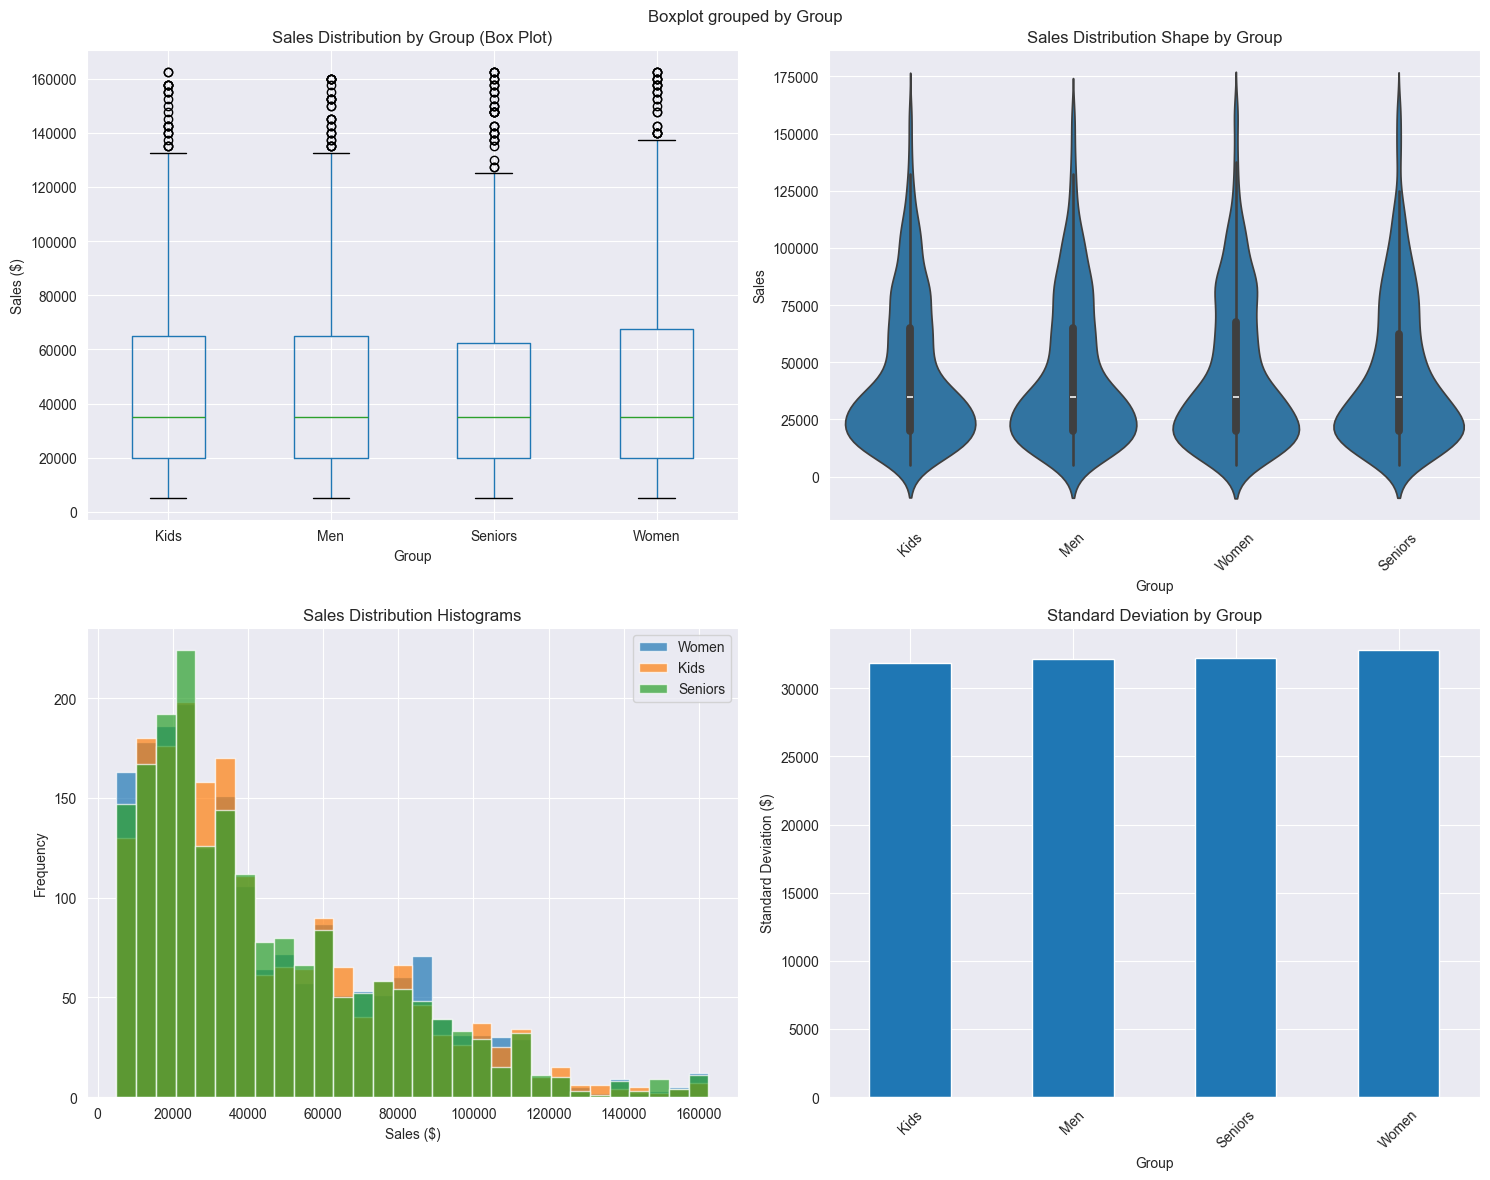


🔍 VARIANCE DECOMPOSITION:
   Women variance: $1,074,635,912.52
    Kids variance: $1,015,791,943.96
 Seniors variance: $1,036,541,206.61

Total variance: $1,040,288,710.18
Within-group variance: $1,042,323,021.03
Between-group variance: $-2,034,310.85
Variance ratio (between/within): -0.0020


In [65]:
# 5. Percentile analysis
print(f"\n📊 PERCENTILE DISTRIBUTION:")
print("=" * 60)
percentiles = [25, 50, 75, 90, 95]
for group in ['Women', 'Kids', 'Seniors']:
    group_data = sales[sales['Group'] == group]['Sales']
    print(f"\n{group} Group:")
    for p in percentiles:
        val = np.percentile(group_data, p)
        print(f"  {p:2d}th percentile: ${val:,.2f}")
# 6. Visualization of variance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Box plot showing distribution and variance
sales.boxplot(column='Sales', by='Group', ax=axes[0, 0])
axes[0, 0].set_title('Sales Distribution by Group (Box Plot)')
axes[0, 0].set_xlabel('Group')
axes[0, 0].set_ylabel('Sales ($)')

# Violin plot for distribution shape
sns.violinplot(data=sales, x='Group', y='Sales', ax=axes[0, 1])
axes[0, 1].set_title('Sales Distribution Shape by Group')
axes[0, 1].tick_params(axis='x', rotation=45)

# Histogram comparison
for i, group in enumerate(['Women', 'Kids', 'Seniors']):
    group_data = sales[sales['Group'] == group]['Sales']
    axes[1, 0].hist(group_data, alpha=0.7, label=group, bins=30)
axes[1, 0].set_title('Sales Distribution Histograms')
axes[1, 0].set_xlabel('Sales ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Standard deviation comparison
group_std = sales.groupby('Group')['Sales'].std()
group_std.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Standard Deviation by Group')
axes[1, 1].set_xlabel('Group')
axes[1, 1].set_ylabel('Standard Deviation ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 7. Variance decomposition
print(f"\n🔍 VARIANCE DECOMPOSITION:")
print("=" * 60)
total_variance = sales['Sales'].var()
within_group_variance = 0
group_sizes = []

for group in ['Women', 'Kids', 'Seniors']:
    group_data = sales[sales['Group'] == group]['Sales']
    group_var = group_data.var()
    group_size = len(group_data)
    group_sizes.append(group_size)
    within_group_variance += (group_size - 1) * group_var
    print(f"{group:>8} variance: ${group_var:,.2f}")

within_group_variance = within_group_variance / (sum(group_sizes) - 3)
between_group_variance = total_variance - within_group_variance

print(f"\nTotal variance: ${total_variance:,.2f}")
print(f"Within-group variance: ${within_group_variance:,.2f}")
print(f"Between-group variance: ${between_group_variance:,.2f}")
print(f"Variance ratio (between/within): {between_group_variance / within_group_variance:.4f}")

### Time based analysis

In [66]:
# Weekly Reports
tu.print_heading("Weekly Sales Report")
weekly_sales = sales.groupby(['Week', 'State'])['Sales'].sum().unstack(fill_value=0)
print(wr.add_commas(weekly_sales.head(10)))

# Monthly Reports
tu.print_heading("Monthly Sales Report")
monthly_sales = sales.groupby(['Month', 'State'])['Sales'].sum().unstack(fill_value=0)
print(wr.add_commas(monthly_sales))

# Quarterly Reports
tu.print_heading("Quarterly Sales Report")
quarterly_sales = sales.groupby(['Quarter', 'State'])['Sales'].sum().unstack(fill_value=0)
print(wr.add_commas(quarterly_sales))


State           NSW            NT           QLD            SA           TAS  \
Week                                                                          
40     3,382,500.00  1,052,500.00  1,627,500.00  2,542,500.00  1,052,500.00   
41     5,892,500.00  1,937,500.00  2,545,000.00  4,942,500.00  1,947,500.00   
42     5,717,500.00  1,935,000.00  2,637,500.00  4,822,500.00  1,845,000.00   
43     5,922,500.00  1,907,500.00  2,592,500.00  4,832,500.00  1,907,500.00   
44     4,822,500.00  1,520,000.00  1,997,500.00  3,987,500.00  1,477,500.00   
45     4,915,000.00  1,150,000.00  1,825,000.00  3,772,500.00  1,312,500.00   
46     4,957,500.00  1,247,500.00  1,905,000.00  3,650,000.00  1,287,500.00   
47     4,987,500.00  1,282,500.00  1,875,000.00  3,572,500.00  1,227,500.00   
48     5,147,500.00  1,267,500.00  1,957,500.00  3,555,000.00  1,300,000.00   
49     6,277,500.00  1,937,500.00  2,997,500.00  5,002,500.00  2,097,500.00   

State           VIC            WA  
Week           

State            NSW            NT            QLD             SA  \
Month                                                              
10     25,007,500.00  8,222,500.00  11,120,000.00  20,610,000.00   
11     21,490,000.00  5,257,500.00   8,110,000.00  15,532,500.00   
12     28,472,500.00  9,100,000.00  14,187,500.00  22,715,000.00   

State           TAS            VIC            WA  
Month                                             
10     8,015,000.00  33,442,500.00  7,872,500.00  
11     5,545,000.00  29,530,000.00  5,217,500.00  
12     9,200,000.00  42,592,500.00  9,062,500.00  


State              NSW             NT            QLD             SA  \
Quarter                                                               
4        74,970,000.00  22,580,000.00  33,417,500.00  58,857,500.00   

State              TAS             VIC             WA  
Quarter                                                
4        22,760,000.00  105,565,000.00  22,152,500.00  


### Data Visualizations

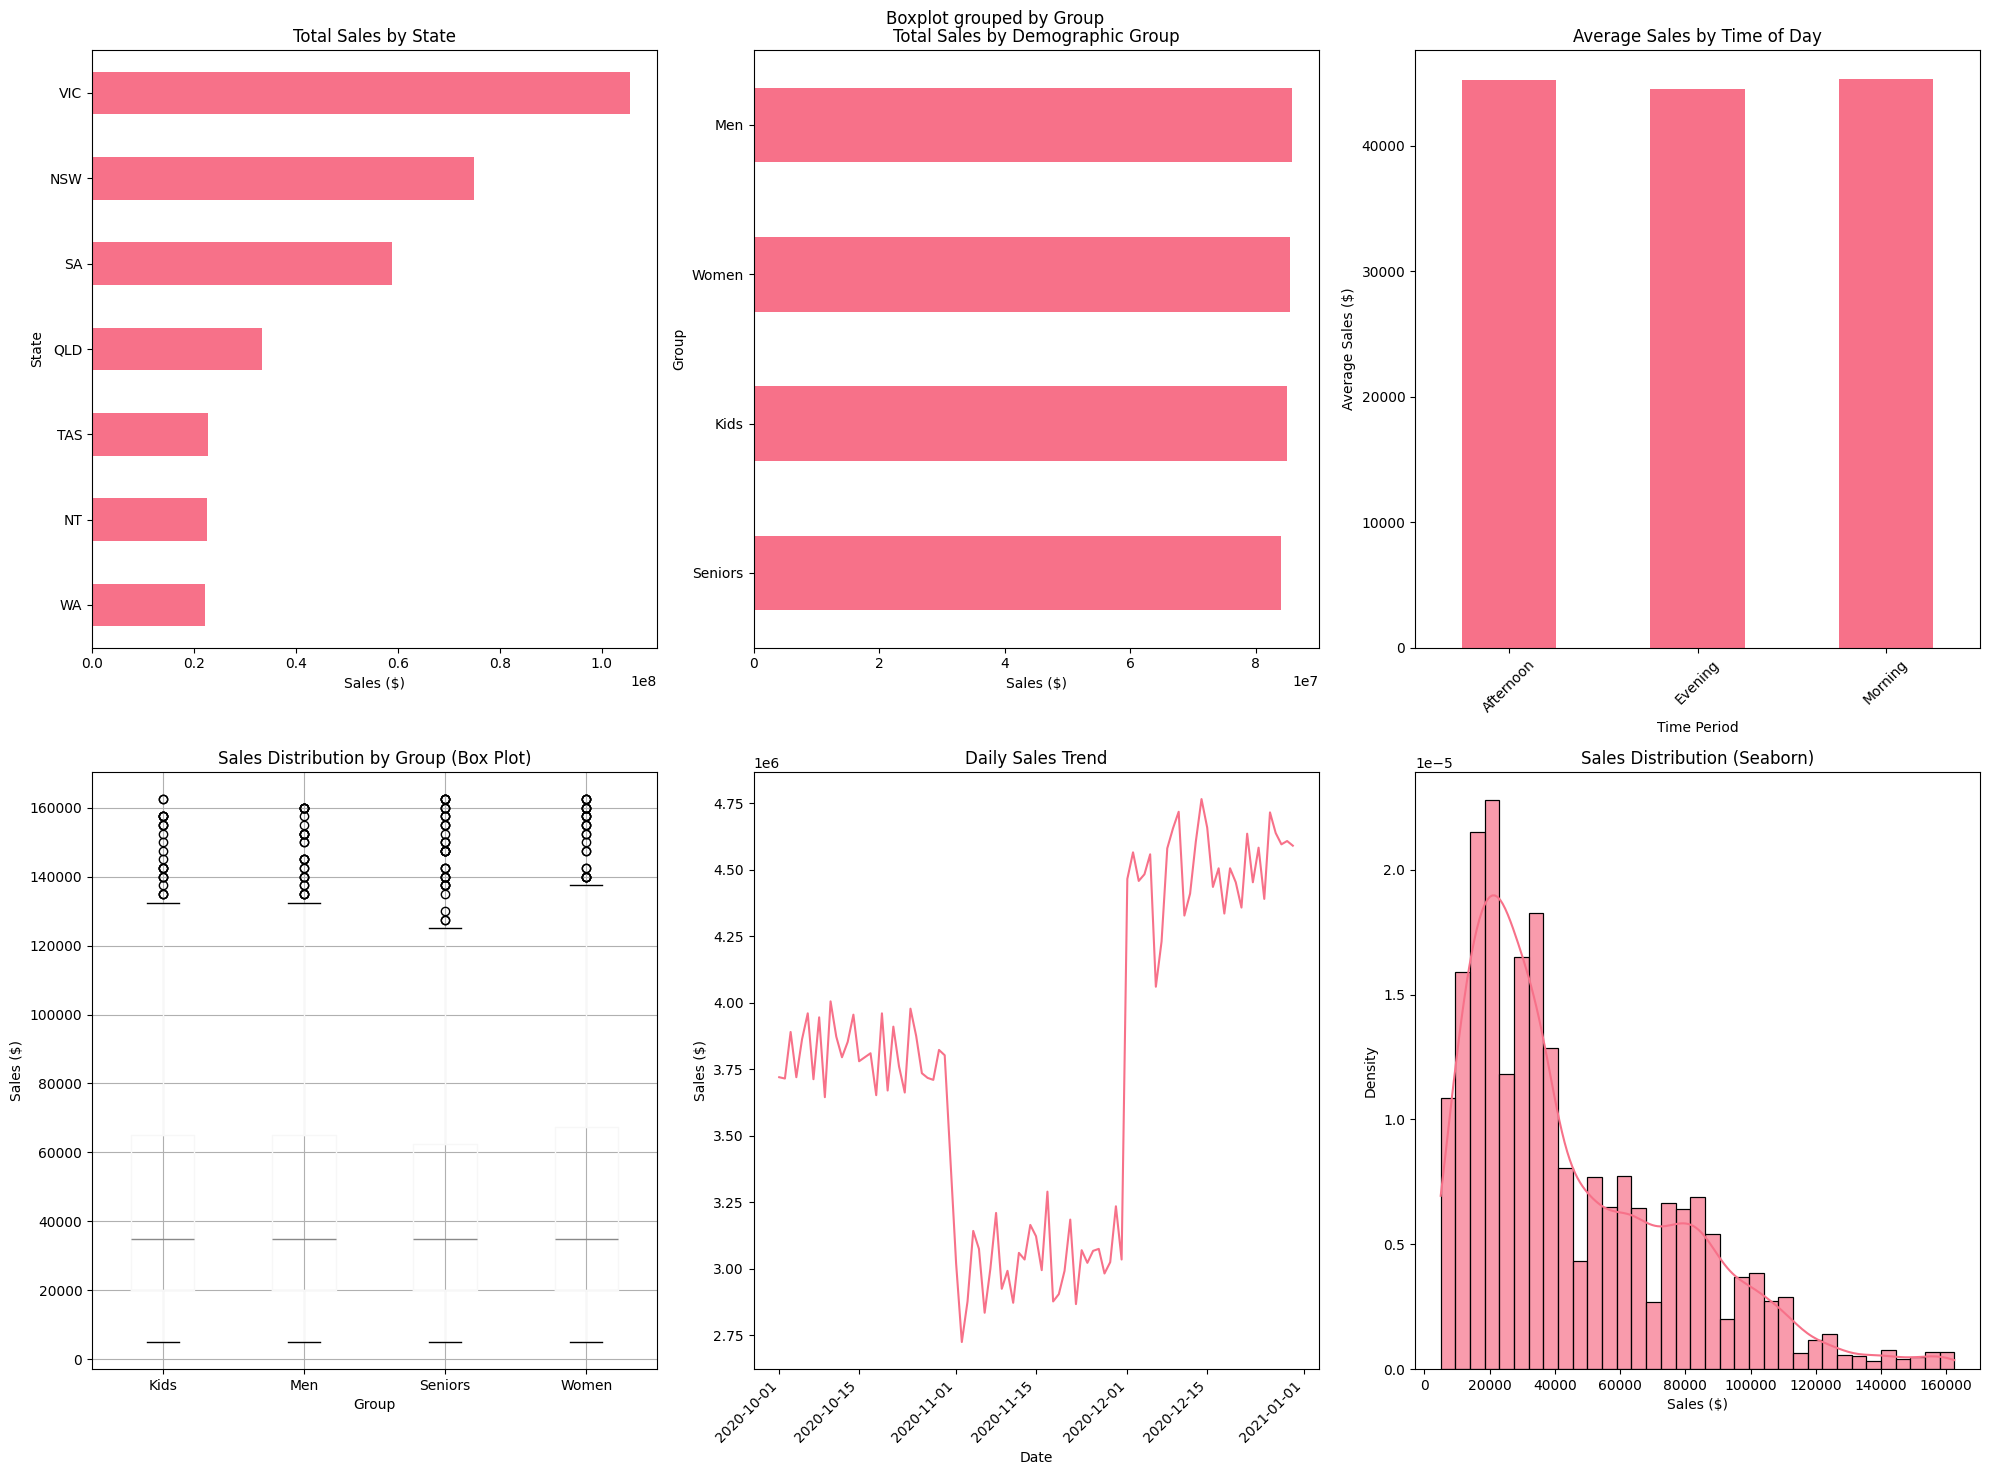

In [67]:
# 3. Data Visualization
tu.print_heading("3. DATA VISUALIZATION")

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create figure with multiple subplots for dashboard
fig = plt.figure(figsize=(20, 15))

# 1. State-wise sales analysis
plt.subplot(2, 3, 1)
state_sales_viz = sales.groupby('State')['Sales'].sum().sort_values(ascending=True)
state_sales_viz.plot(kind='barh')
plt.title('Total Sales by State')
plt.xlabel('Sales ($)')

# 2. Group-wise sales analysis
plt.subplot(2, 3, 2)
group_sales_viz = sales.groupby('Group')['Sales'].sum().sort_values(ascending=True)
group_sales_viz.plot(kind='barh')
plt.title('Total Sales by Demographic Group')
plt.xlabel('Sales ($)')

# 3. Time of day analysis
plt.subplot(2, 3, 3)
time_sales = sales.groupby('Time')['Sales'].mean()
time_sales.plot(kind='bar')
plt.title('Average Sales by Time of Day')
plt.xlabel('Time Period')
plt.ylabel('Average Sales ($)')
plt.xticks(rotation=45)

# 4. Box plot for descriptive statistics (as required)
plt.subplot(2, 3, 4)
sales.boxplot(column='Sales', by='Group', ax=plt.gca())
plt.title('Sales Distribution by Group (Box Plot)')
plt.xlabel('Group')
plt.ylabel('Sales ($)')

# 5. Daily sales trend
plt.subplot(2, 3, 5)
daily_sales = sales.groupby('Date')['Sales'].sum()
daily_sales.plot()
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)

# 6. Seaborn distribution plot (as required)
plt.subplot(2, 3, 6)
#sns.histplot(sales['Sales'], kde=True)
sns.histplot(data=sales, x='Sales', kde=True, stat='density', alpha=0.7)
plt.title('Sales Distribution (Seaborn)')
plt.xlabel('Sales ($)')


plt.tight_layout()
plt.show()

### Additional visualizatoins

<Figure size 1500x1000 with 0 Axes>

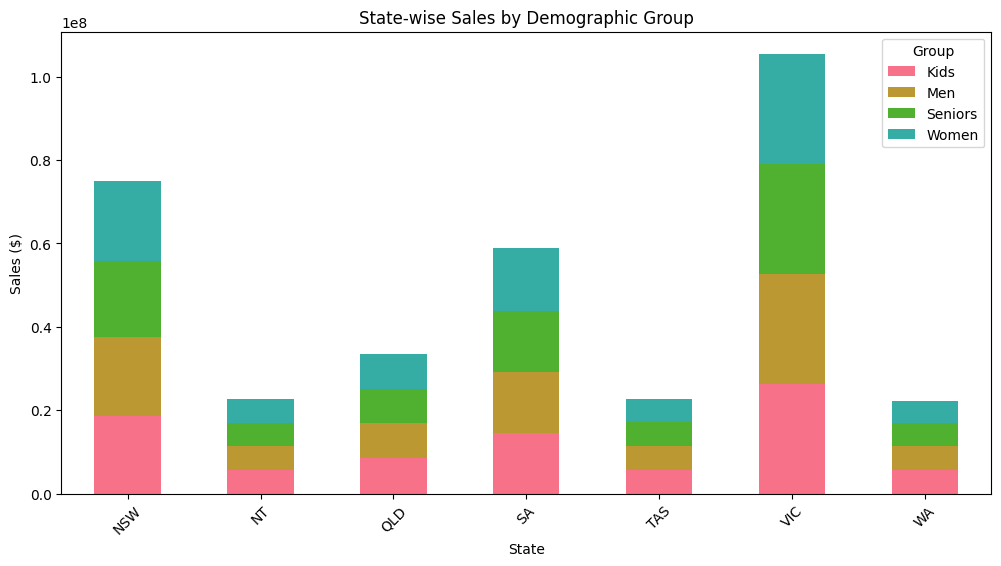

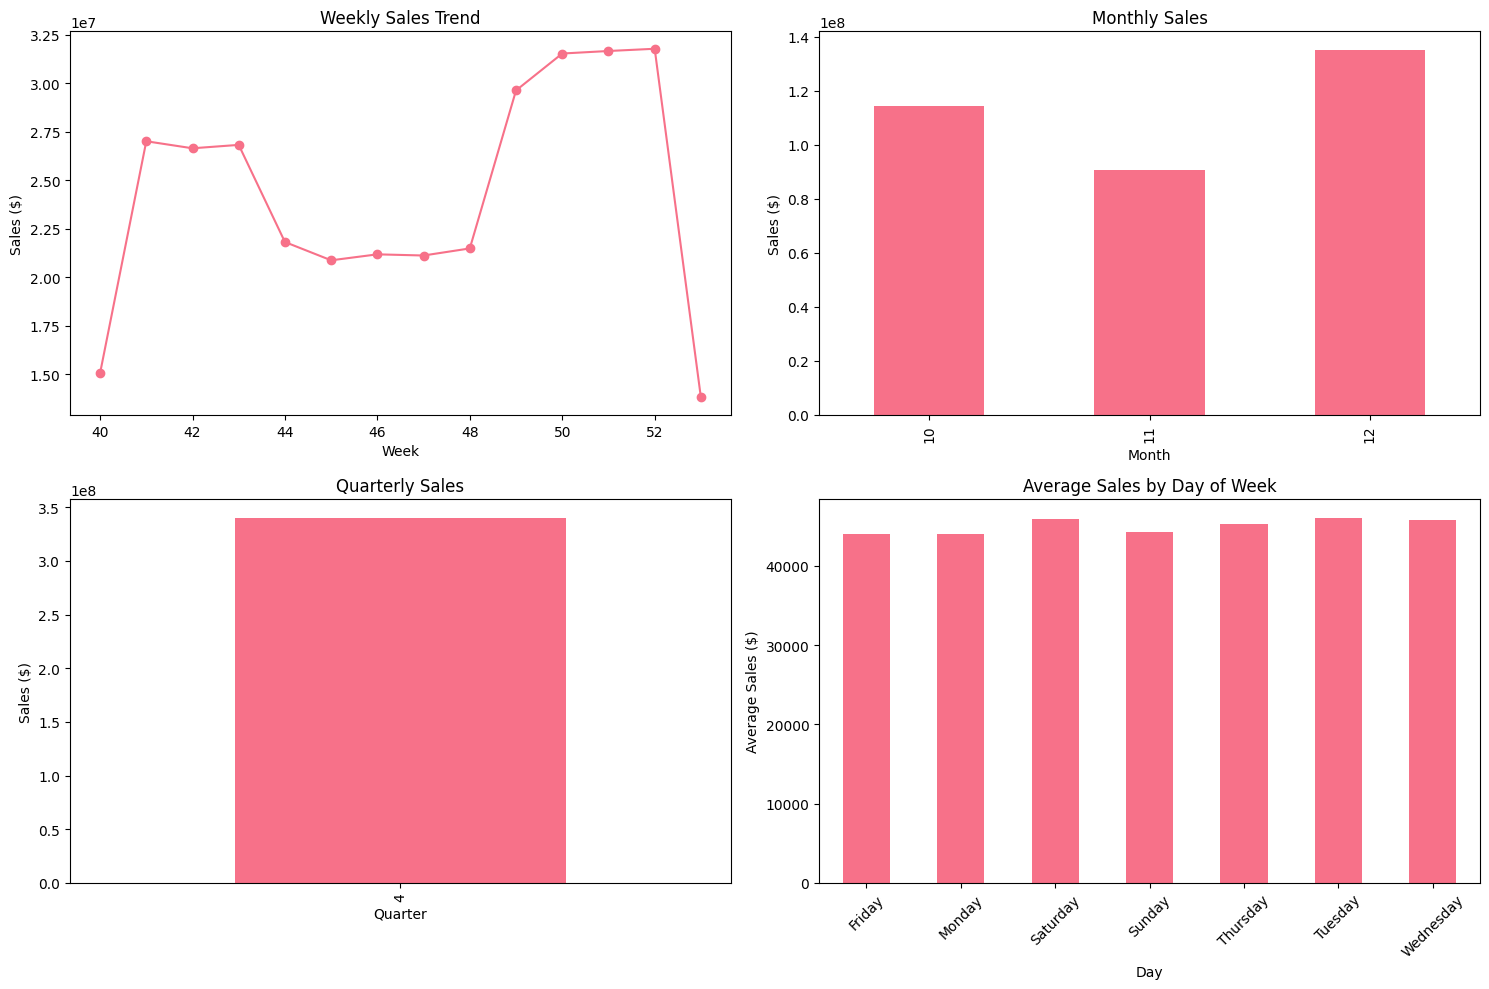

In [68]:
# Detailed State-wise and Group-wise Analysis
tu.print_heading("Detailed Visualization Analysis")

# State-wise sales by demographic group
plt.figure(figsize=(15, 10))
pivot_state_group = sales.groupby(['State', 'Group'])['Sales'].sum().unstack()
pivot_state_group.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('State-wise Sales by Demographic Group')
plt.xlabel('State')
plt.ylabel('Sales ($)')
plt.legend(title='Group')
plt.xticks(rotation=45)
plt.show()

# Time-based analysis charts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Weekly chart
weekly_total = sales.groupby('Week')['Sales'].sum()
weekly_total.plot(ax=axes[0,0], kind='line', marker='o')
axes[0,0].set_title('Weekly Sales Trend')
axes[0,0].set_xlabel('Week')
axes[0,0].set_ylabel('Sales ($)')

# Monthly chart
monthly_total = sales.groupby('Month')['Sales'].sum()
monthly_total.plot(ax=axes[0,1], kind='bar')
axes[0,1].set_title('Monthly Sales')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Sales ($)')

# Quarterly chart
quarterly_total = sales.groupby('Quarter')['Sales'].sum()
quarterly_total.plot(ax=axes[1,0], kind='bar')
axes[1,0].set_title('Quarterly Sales')
axes[1,0].set_xlabel('Quarter')
axes[1,0].set_ylabel('Sales ($)')

# Daily average by day of week
sales['DayOfWeek'] = sales['Date'].dt.day_name()
daily_avg = sales.groupby('DayOfWeek')['Sales'].mean()
daily_avg.plot(ax=axes[1,1], kind='bar')
axes[1,1].set_title('Average Sales by Day of Week')
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Average Sales ($)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Report with recommendations

In [69]:
# 4. Report Generation and Recommendations
tu.print_heading("4. REPORT GENERATION & RECOMMENDATIONS")

tu.print_heading("Key Findings and Recommendations")

# Calculate key metrics for recommendations
highest_state = sales.groupby('State')['Sales'].sum().idxmax()
lowest_state = sales.groupby('State')['Sales'].sum().idxmin()
best_time = sales.groupby('Time')['Sales'].mean().idxmax()
best_group = sales.groupby('Group')['Sales'].sum().idxmax()

print("📊 KEY FINDINGS:")
print("=" * 50)
print(f"• Highest Revenue State: {highest_state}")
print(f"• Lowest Revenue State: {lowest_state}")
print(f"• Best Performing Time: {best_time}")
print(f"• Best Performing Group: {best_group}")
print(f"• Total Q4 Revenue: ${sales['Sales'].sum():,.2f}")
print(f"• Average Daily Revenue: ${sales.groupby('Date')['Sales'].sum().mean():,.2f}")

print("\n🎯 RECOMMENDATIONS:")
print("=" * 50)
print(f"1. EXPAND IN HIGH-PERFORMING STATES:")
print(f"   - Focus expansion efforts in {highest_state} which shows highest revenue")
print(f"   - Replicate successful strategies from {highest_state} in other states")

print(f"\n2. DEVELOP PROGRAMS FOR LOWER-PERFORMING STATES:")
print(f"   - Create targeted marketing campaigns for {lowest_state}")
print(f"   - Investigate local preferences and adjust product mix")

print(f"\n3. OPTIMIZE TIME-BASED OPERATIONS:")
print(f"   - Peak sales period is {best_time} - ensure adequate staffing")
print(f"   - Consider promotional activities during off-peak hours")

print(f"\n4. DEMOGRAPHIC FOCUS:")
print(f"   - {best_group} segment generates highest revenue - maintain focus")
print(f"   - Develop targeted campaigns for underperforming segments")

print("\n📈 VISUALIZATION PACKAGE RECOMMENDATION:")
print("=" * 50)
print("SEABORN is recommended because:")
print("• Specifically designed for statistical data visualization")
print("• Excellent integration with pandas DataFrames")
print("• Beautiful default color palettes and themes")
print("• Built-in statistical plotting functions")
print("• Perfect for business intelligence dashboards")


📊 KEY FINDINGS:
• Highest Revenue State: VIC
• Lowest Revenue State: WA
• Best Performing Time: Morning
• Best Performing Group: Men
• Total Q4 Revenue: $340,302,500.00
• Average Daily Revenue: $3,781,138.89

🎯 RECOMMENDATIONS:
1. EXPAND IN HIGH-PERFORMING STATES:
   - Focus expansion efforts in VIC which shows highest revenue
   - Replicate successful strategies from VIC in other states

2. DEVELOP PROGRAMS FOR LOWER-PERFORMING STATES:
   - Create targeted marketing campaigns for WA
   - Investigate local preferences and adjust product mix

3. OPTIMIZE TIME-BASED OPERATIONS:
   - Peak sales period is Morning - ensure adequate staffing
   - Consider promotional activities during off-peak hours

4. DEMOGRAPHIC FOCUS:
   - Men segment generates highest revenue - maintain focus
   - Develop targeted campaigns for underperforming segments

📈 VISUALIZATION PACKAGE RECOMMENDATION:
SEABORN is recommended because:
• Specifically designed for statistical data visualization
• Excellent integrati